# Practical Lab 1: Predictive Maintenance with Linear Regression-Based Alerts

This notebook fits time-to-current regression models for eight robot axes, analyzes residuals, and detects sustained Alert and Error events. It compares local CSV training with data read back from Neon PostgreSQL, then creates standardized synthetic test data and streams a small test batch using database-derived training statistics.

Run from the project root so relative paths resolve correctly. The CSV workflow runs locally. Neon is required only for the database-backed training and streaming sections. Injected anomalies are test cases, not confirmed robot faults.

## 1. Load and inspect the source data

The CSV contains the robot telemetry used throughout the lab. These cells read the file, preview rows and columns, inspect data types and missing values, and summarize the eight joint-current axes. This initial inspection helps confirm the expected data is available before modeling.

In [14]:
import pandas as pd

df = pd.read_csv("dataset/RMBR4-2_export_test.csv")

print("CSV loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

CSV loaded successfully!
Rows: 39672
Columns: 16


In [15]:
df.head()

,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


In [16]:
print(df.columns.tolist())

['Trait', 'Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14', 'Time']


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39672 entries, 0 to 39671
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Trait     39672 non-null  str    
 1   Axis #1   39672 non-null  float64
 2   Axis #2   39672 non-null  float64
 3   Axis #3   39672 non-null  float64
 4   Axis #4   39672 non-null  float64
 5   Axis #5   39672 non-null  float64
 6   Axis #6   39672 non-null  float64
 7   Axis #7   39672 non-null  float64
 8   Axis #8   39672 non-null  float64
 9   Axis #9   0 non-null      float64
 10  Axis #10  0 non-null      float64
 11  Axis #11  0 non-null      float64
 12  Axis #12  0 non-null      float64
 13  Axis #13  0 non-null      float64
 14  Axis #14  0 non-null      float64
 15  Time      39672 non-null  str    
dtypes: float64(14), str(2)
memory usage: 4.8 MB


In [18]:
df["Time"] = pd.to_datetime(df["Time"], utc=True)

print(df["Time"].dtype)

datetime64[us, UTC]


In [19]:
df.isnull().sum()

Trait           0
Axis #1         0
Axis #2         0
Axis #3         0
Axis #4         0
Axis #5         0
Axis #6         0
Axis #7         0
Axis #8         0
Axis #9     39672
Axis #10    39672
Axis #11    39672
Axis #12    39672
Axis #13    39672
Axis #14    39672
Time            0
dtype: int64

In [20]:
axes = [f"Axis #{i}" for i in range(1, 9)]

print(df[axes].isnull().sum())

Axis #1    0
Axis #2    0
Axis #3    0
Axis #4    0
Axis #5    0
Axis #6    0
Axis #7    0
Axis #8    0
dtype: int64


In [21]:
df[axes].describe()

,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
count,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000
mean,0.725743,3.613374,2.710336,0.620222,0.954521,0.599427,0.870145,0.102214
std,2.162120,6.879962,5.111901,1.574897,2.100186,1.815498,2.166811,0.423075
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.312710,4.217190,4.586190,0.516190,0.800090,0.361330,0.310030,0.078480
max,23.609300,51.713230,41.855560,15.666300,20.750760,20.931420,8.108480,5.905640


## 2. Prepare time and fit a baseline for Axis #1

Timestamps are converted to UTC and then represented as elapsed seconds from the first reading. A `LinearRegression` model uses elapsed time as its feature and Axis #1 current as its target. The fitted slope and intercept describe the simple time-based baseline; the following cells use it to calculate predicted values and residuals.

In [22]:
df["Time_seconds"] = (
    df["Time"] - df["Time"].min()
).dt.total_seconds()

print(df[["Time", "Time_seconds"]].head())

                              Time  Time_seconds
0 2022-10-17 12:18:23.660000+00:00         0.000
1 2022-10-17 12:18:25.472000+00:00         1.812
2 2022-10-17 12:18:27.348000+00:00         3.688
3 2022-10-17 12:18:29.222000+00:00         5.562
4 2022-10-17 12:18:31.117000+00:00         7.457


In [23]:
from sklearn.linear_model import LinearRegression

print("Linear Regression is ready!")

Linear Regression is ready!


In [24]:
X = df[["Time_seconds"]]
y = df["Axis #1"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39672, 1)
y shape: (39672,)


In [25]:
model_axis1 = LinearRegression()

model_axis1.fit(X, y)

print("Axis #1 regression model trained!")

Axis #1 regression model trained!


In [26]:
print("Axis #1 Slope:", model_axis1.coef_[0])
print("Axis #1 Intercept:", model_axis1.intercept_)

Axis #1 Slope: -1.1767285669287817e-07
Axis #1 Intercept: 0.730542085743738


In [27]:
print("Axis #1 Slope:", model_axis1.coef_[0])
print("Axis #1 Intercept:", model_axis1.intercept_)

Axis #1 Slope: -1.1767285669287817e-07
Axis #1 Intercept: 0.730542085743738


In [28]:
df["Axis1_predicted"] = model_axis1.predict(X)

print(df[["Time_seconds", "Axis #1", "Axis1_predicted"]].head())

   Time_seconds  Axis #1  Axis1_predicted
0         0.000      0.0         0.730542
1         1.812      0.0         0.730542
2         3.688      0.0         0.730542
3         5.562      0.0         0.730541
4         7.457      0.0         0.730541


In [29]:
df["Axis1_residual"] = df["Axis #1"] - df["Axis1_predicted"]

print(df[["Axis #1", "Axis1_predicted", "Axis1_residual"]].head())

   Axis #1  Axis1_predicted  Axis1_residual
0      0.0         0.730542       -0.730542
1      0.0         0.730542       -0.730542
2      0.0         0.730542       -0.730542
3      0.0         0.730541       -0.730541
4      0.0         0.730541       -0.730541


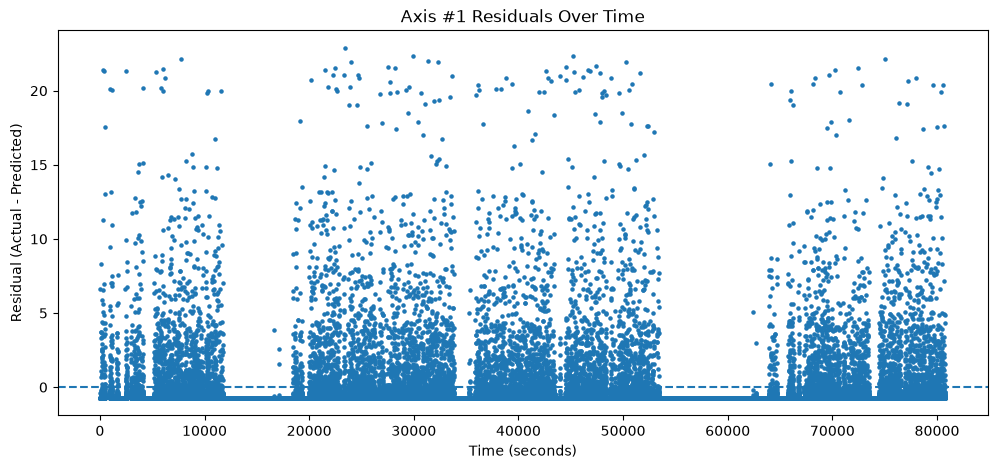

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.scatter(
    df["Time_seconds"],
    df["Axis1_residual"],
    s=5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time (seconds)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Axis #1 Residuals Over Time")

plt.show()

## 3. Inspect residuals and candidate anomaly thresholds

A residual is the observed current minus the model prediction. The scatter plot and summary statistics show how far Axis #1 readings deviate from the baseline; sorting the largest residuals surfaces the most unusual positive deviations. The percentile calculations provide data-derived cutoffs for exploratory high-residual analysis.

In [31]:
df["Axis1_residual"].describe()

count    3.967200e+04
mean    -5.731339e-17
std      2.162118e+00
min     -7.305421e-01
25%     -7.268099e-01
50%     -7.233406e-01
75%     -4.153363e-01
max      2.288151e+01
Name: Axis1_residual, dtype: float64

In [32]:
df["Axis1_residual"].describe()

count    3.967200e+04
mean    -5.731339e-17
std      2.162118e+00
min     -7.305421e-01
25%     -7.268099e-01
50%     -7.233406e-01
75%     -4.153363e-01
max      2.288151e+01
Name: Axis1_residual, dtype: float64

In [33]:
df[["Time", "Axis #1", "Axis1_predicted", "Axis1_residual"]].sort_values(
    "Axis1_residual",
    ascending=False
).head(10)

,Time,Axis #1,Axis1_predicted,Axis1_residual
11214,2022-10-17 18:48:20.182000+00:00,23.60930,0.727789,22.881511
14423,2022-10-17 20:36:53.459000+00:00,23.08812,0.727023,22.361097
22005,2022-10-18 00:51:37.440000+00:00,23.03601,0.725224,22.310786
3486,2022-10-17 14:27:40.538000+00:00,22.85359,0.729629,22.123961
36801,2022-10-18 09:08:24.708000+00:00,22.82754,0.721716,22.105824
15137,2022-10-17 21:00:55.563000+00:00,22.74936,0.726853,22.022507
24527,2022-10-18 02:16:31.322000+00:00,22.64512,0.724625,21.920495
15589,2022-10-17 21:16:12.163000+00:00,22.64512,0.726745,21.918375
11502,2022-10-17 18:58:00.929000+00:00,22.64512,0.727721,21.917399
23098,2022-10-18 01:28:26.924000+00:00,22.38453,0.724964,21.659566


## 4. Find continuous high-residual periods

The next cells flag readings at or above the 95th percentile and group adjacent flagged readings into runs. Comparing timestamps gives each run a duration. The corrected grouping also starts a new run when the time gap between readings exceeds five seconds, so missing stretches are not counted as continuous activity. A stricter 99th-percentile threshold is examined as well.

In [34]:
print("95th percentile:", df["Axis1_residual"].quantile(0.95))
print("99th percentile:", df["Axis1_residual"].quantile(0.99))
print("99.5th percentile:", df["Axis1_residual"].quantile(0.995))
print("99.9th percentile:", df["Axis1_residual"].quantile(0.999))

95th percentile: 3.622423285277967
99th percentile: 10.637570249828158
99.5th percentile: 13.023465104864359
99.9th percentile: 20.834316803092815


In [35]:
df["above_95"] = df["Axis1_residual"] >= df["Axis1_residual"].quantile(0.95)

print("Number of readings above 95th percentile:")
print(df["above_95"].sum())

Number of readings above 95th percentile:
1984


In [36]:
df["Time_gap_seconds"] = df["Time_seconds"].diff()

print(df["Time_gap_seconds"].describe())

count    39671.000000
mean         2.036625
std          2.713063
min          1.714000
25%          1.860000
50%          1.891000
75%          1.923000
max        402.538000
Name: Time_gap_seconds, dtype: float64


In [37]:
# Create a group number whenever the True/False status changes
df["run_id"] = df["above_95"].ne(df["above_95"].shift()).cumsum()

# Keep only periods where the residual is above the 95th percentile
runs = df[df["above_95"]].groupby("run_id").agg(
    start_time=("Time", "min"),
    end_time=("Time", "max"),
    readings=("above_95", "size")
)

# Calculate duration in seconds
runs["duration_seconds"] = (
    runs["end_time"] - runs["start_time"]
).dt.total_seconds()

# Show the longest runs
runs.sort_values("duration_seconds", ascending=False).head(10)

,start_time,end_time,readings,duration_seconds
run_id,,,,
1998,2022-10-17 23:59:51.069000+00:00,2022-10-18 00:00:00.846000+00:00,4,9.777
1240,2022-10-17 20:22:12.028000+00:00,2022-10-17 20:22:19.431000+00:00,3,7.403
2966,2022-10-18 07:38:43.489000+00:00,2022-10-18 07:38:50.867000+00:00,3,7.378
1376,2022-10-17 20:53:27.054000+00:00,2022-10-17 20:53:32.690000+00:00,2,5.636
954,2022-10-17 19:08:56.362000+00:00,2022-10-17 19:09:01.909000+00:00,2,5.547
132,2022-10-17 13:24:13.851000+00:00,2022-10-17 13:24:19.386000+00:00,2,5.535
2456,2022-10-18 02:10:52.478000+00:00,2022-10-18 02:10:56.446000+00:00,3,3.968
764,2022-10-17 18:23:26.814000+00:00,2022-10-17 18:23:30.755000+00:00,3,3.941
800,2022-10-17 18:31:08.641000+00:00,2022-10-17 18:31:12.550000+00:00,3,3.909


In [38]:
print(
    runs["duration_seconds"]
    .sort_values(ascending=False)
    .head(20)
)

run_id
1998    9.777
1240    7.403
2966    7.378
1376    5.636
954     5.547
132     5.535
2456    3.968
764     3.941
800     3.909
2868    3.891
3178    3.888
2608    3.877
3516    3.876
1076    3.875
1052    3.871
196     3.865
1188    3.861
1818    3.855
3496    3.855
3156    3.854
Name: duration_seconds, dtype: float64


In [39]:
# A new run starts when:
# 1. The above/below threshold status changes, OR
# 2. There is a large gap between readings.

gap_limit = 5  # seconds

df["new_run"] = (
    df["above_95"].ne(df["above_95"].shift())
    | (df["Time_gap_seconds"] > gap_limit)
)

df["run_id_corrected"] = df["new_run"].cumsum()

runs_corrected = (
    df[df["above_95"]]
    .groupby("run_id_corrected")
    .agg(
        start_time=("Time", "min"),
        end_time=("Time", "max"),
        readings=("above_95", "size")
    )
)

runs_corrected["duration_seconds"] = (
    runs_corrected["end_time"] -
    runs_corrected["start_time"]
).dt.total_seconds()

runs_corrected = runs_corrected.sort_values(
    "duration_seconds",
    ascending=False
)

runs_corrected.head(10)

,start_time,end_time,readings,duration_seconds
run_id_corrected,,,,
3134,2022-10-18 02:10:52.478000+00:00,2022-10-18 02:10:56.446000+00:00,3,3.968
1069,2022-10-17 18:23:26.814000+00:00,2022-10-17 18:23:30.755000+00:00,3,3.941
1111,2022-10-17 18:31:08.641000+00:00,2022-10-17 18:31:12.550000+00:00,3,3.909
2573,2022-10-17 23:59:56.946000+00:00,2022-10-18 00:00:00.846000+00:00,3,3.900
3819,2022-10-18 07:20:42.315000+00:00,2022-10-18 07:20:46.206000+00:00,3,3.891
4211,2022-10-18 09:01:07.177000+00:00,2022-10-18 09:01:11.065000+00:00,3,3.888
3314,2022-10-18 02:46:36.251000+00:00,2022-10-18 02:46:40.128000+00:00,3,3.877
4603,2022-10-18 10:17:03.737000+00:00,2022-10-18 10:17:07.613000+00:00,3,3.876
1432,2022-10-17 19:34:24.393000+00:00,2022-10-17 19:34:28.268000+00:00,3,3.875


In [40]:
runs_corrected.head(10)

,start_time,end_time,readings,duration_seconds
run_id_corrected,,,,
3134,2022-10-18 02:10:52.478000+00:00,2022-10-18 02:10:56.446000+00:00,3,3.968
1069,2022-10-17 18:23:26.814000+00:00,2022-10-17 18:23:30.755000+00:00,3,3.941
1111,2022-10-17 18:31:08.641000+00:00,2022-10-17 18:31:12.550000+00:00,3,3.909
2573,2022-10-17 23:59:56.946000+00:00,2022-10-18 00:00:00.846000+00:00,3,3.900
3819,2022-10-18 07:20:42.315000+00:00,2022-10-18 07:20:46.206000+00:00,3,3.891
4211,2022-10-18 09:01:07.177000+00:00,2022-10-18 09:01:11.065000+00:00,3,3.888
3314,2022-10-18 02:46:36.251000+00:00,2022-10-18 02:46:40.128000+00:00,3,3.877
4603,2022-10-18 10:17:03.737000+00:00,2022-10-18 10:17:07.613000+00:00,3,3.876
1432,2022-10-17 19:34:24.393000+00:00,2022-10-17 19:34:28.268000+00:00,3,3.875


In [41]:
df["above_99"] = df["Axis1_residual"] >= df["Axis1_residual"].quantile(0.99)

print("Readings above 99th percentile:")
print(df["above_99"].sum())

Readings above 99th percentile:
397


In [42]:
df["new_run_99"] = (
    df["above_99"].ne(df["above_99"].shift())
    | (df["Time_gap_seconds"] > 5)
)

df["run_id_99"] = df["new_run_99"].cumsum()

runs_99 = (
    df[df["above_99"]]
    .groupby("run_id_99")
    .agg(
        start_time=("Time", "min"),
        end_time=("Time", "max"),
        readings=("above_99", "size")
    )
)

runs_99["duration_seconds"] = (
    runs_99["end_time"] - runs_99["start_time"]
).dt.total_seconds()

runs_99 = runs_99.sort_values(
    "duration_seconds",
    ascending=False
)

runs_99.head(10)

,start_time,end_time,readings,duration_seconds
run_id_99,,,,
6,2022-10-17 12:22:45.266000+00:00,2022-10-17 12:22:45.266000+00:00,1,0.0
8,2022-10-17 12:23:08.315000+00:00,2022-10-17 12:23:08.315000+00:00,1,0.0
12,2022-10-17 12:25:02.642000+00:00,2022-10-17 12:25:02.642000+00:00,1,0.0
15,2022-10-17 12:26:01.408000+00:00,2022-10-17 12:26:01.408000+00:00,1,0.0
17,2022-10-17 12:26:14.760000+00:00,2022-10-17 12:26:14.760000+00:00,1,0.0
22,2022-10-17 12:35:06.250000+00:00,2022-10-17 12:35:06.250000+00:00,1,0.0
25,2022-10-17 12:35:55.616000+00:00,2022-10-17 12:35:55.616000+00:00,1,0.0
27,2022-10-17 12:36:56.453000+00:00,2022-10-17 12:36:56.453000+00:00,1,0.0
30,2022-10-17 12:38:22.597000+00:00,2022-10-17 12:38:22.597000+00:00,1,0.0


## 5. Build baseline models for all eight axes

Each joint axis gets its own linear-regression model using the same elapsed-time feature. The notebook stores each model, its predictions, and its residuals, then plots actual values against their baselines and compares residual distributions. This generalizes the earlier Axis #1 exploration to all axes used by the detector.

In [ ]:
MinC = round(float(df["Axis1_residual"].quantile(0.95)), 2)
MaxC = round(float(df["Axis1_residual"].quantile(0.99)), 2)
T = 4

print("Axis #1 training residual 95th percentile:", df["Axis1_residual"].quantile(0.95))
print("Axis #1 training residual 99th percentile:", df["Axis1_residual"].quantile(0.99))
print("MinC (Alert):", MinC, "kWh")
print("MaxC (Error):", MaxC, "kWh")
print("T (minimum duration):", T, "seconds")

In [44]:
# Store all regression models here
models = {}

# Store predictions and residuals for each axis
for i in range(1, 9):

    axis_name = f"Axis #{i}"

    # X = time
    X_axis = df[["Time_seconds"]]

    # Y = current values for this axis
    y_axis = df[axis_name]

    # Create and train the model
    model = LinearRegression()
    model.fit(X_axis, y_axis)

    # Save the model
    models[axis_name] = model

    # Create prediction column
    df[f"{axis_name}_predicted"] = model.predict(X_axis)

    # Create residual column
    df[f"{axis_name}_residual"] = (
        df[axis_name] - df[f"{axis_name}_predicted"]
    )

    print(
        axis_name,
        "| Slope:", model.coef_[0],
        "| Intercept:", model.intercept_
    )

Axis #1 | Slope: -1.1767285669287817e-07 | Intercept: 0.730542085743738
Axis #2 | Slope: 2.1942034174285988e-06 | Intercept: 3.52388581901242
Axis #3 | Slope: -5.77718596038158e-07 | Intercept: 2.733897883456504
Axis #4 | Slope: 3.8900344647278664e-07 | Intercept: 0.6043568012838468
Axis #5 | Slope: 8.381177886041457e-08 | Intercept: 0.951102757917077
Axis #6 | Slope: 4.7444554719057845e-07 | Intercept: 0.5800773618963682


Axis #7 | Slope: 5.5371861542022e-07 | Intercept: 0.8475626287465717
Axis #8 | Slope: 8.499988745963795e-08 | Intercept: 0.09874786274985085


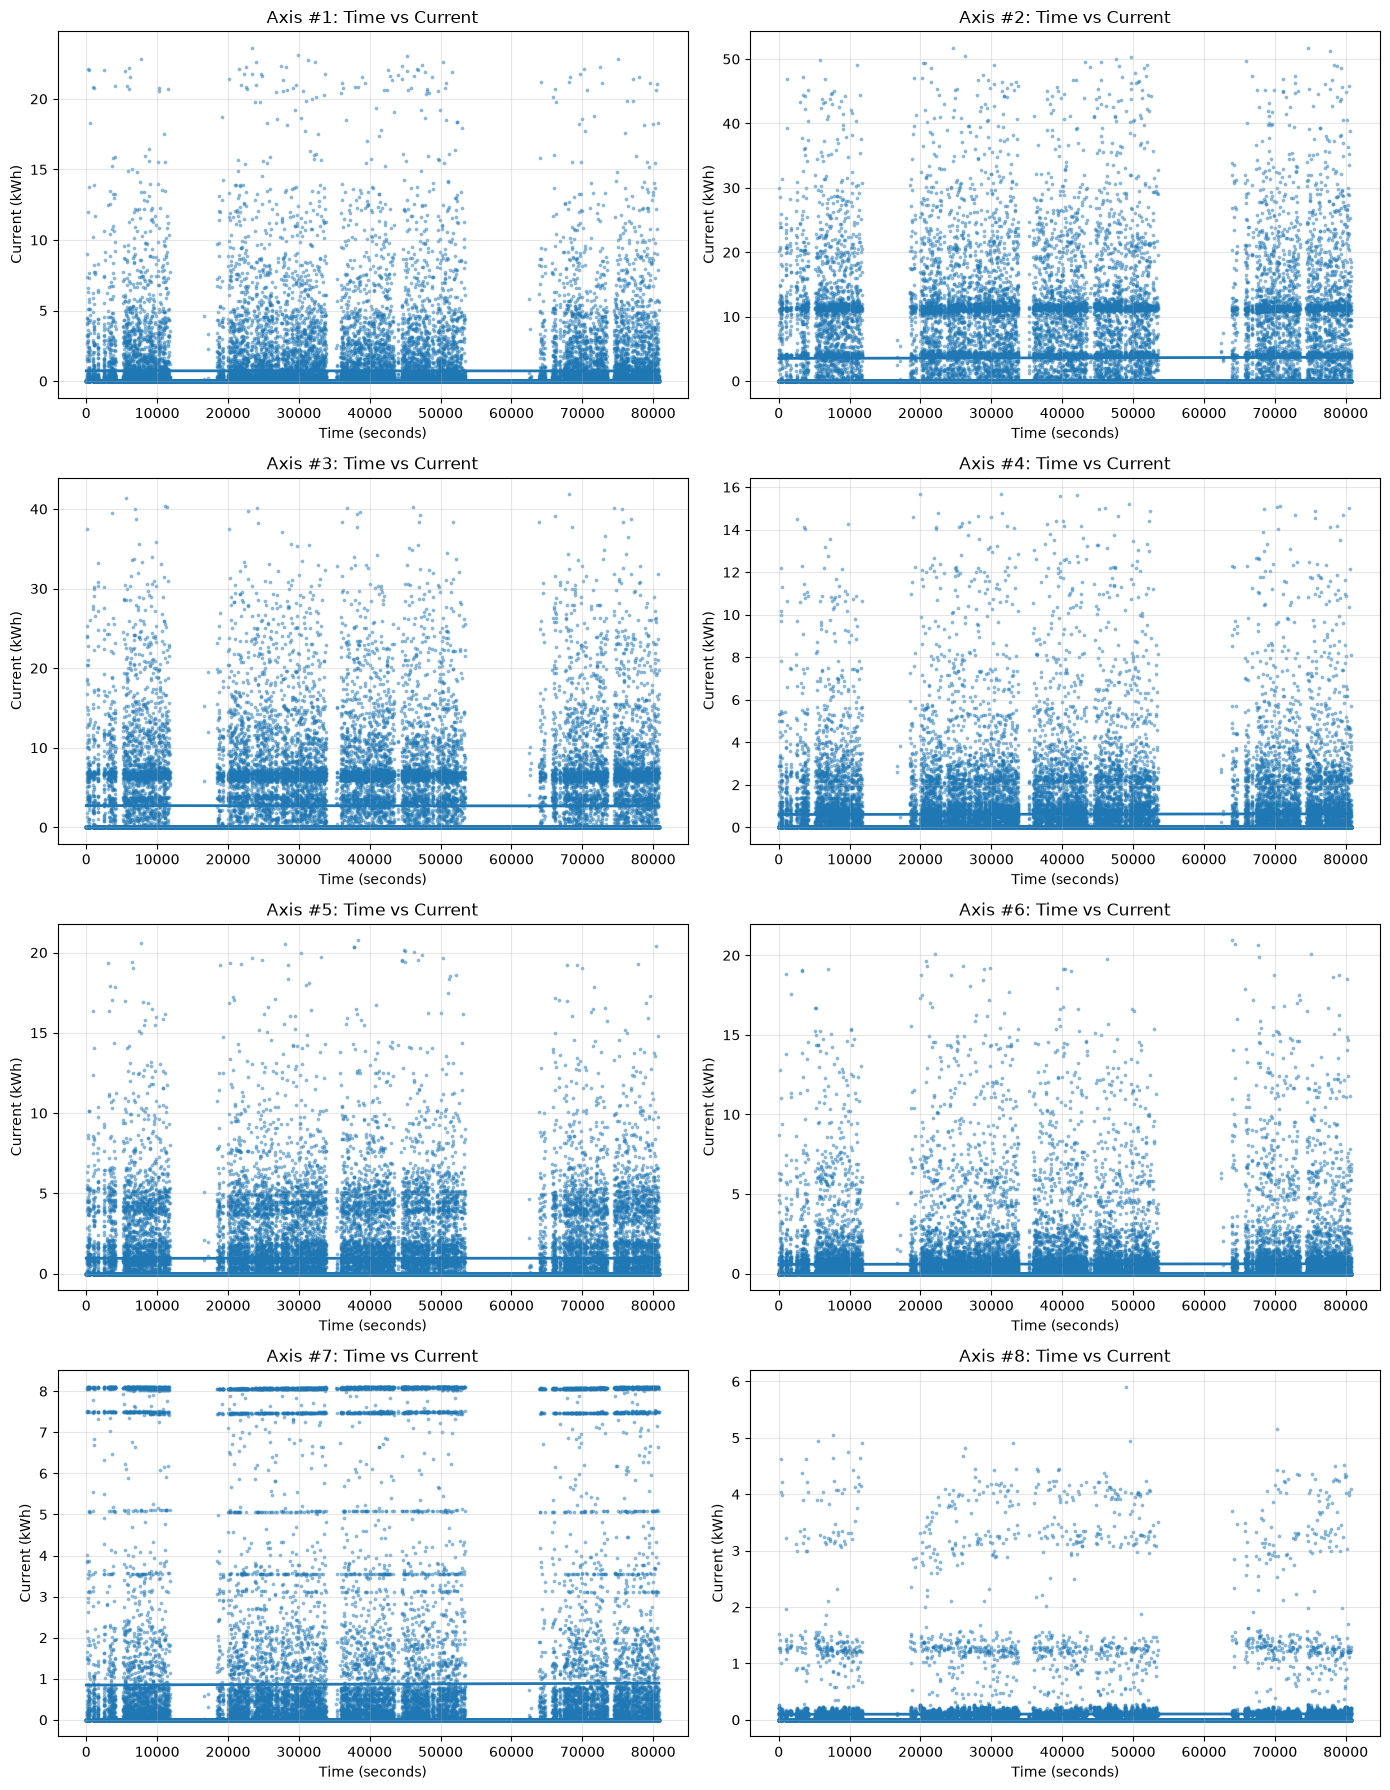

In [45]:
fig, axes_plot = plt.subplots(4, 2, figsize=(14, 18))

for i, ax in enumerate(axes_plot.flatten(), start=1):

    axis_name = f"Axis #{i}"

    # Actual data
    ax.scatter(
        df["Time_seconds"],
        df[axis_name],
        s=3,
        alpha=0.4
    )

    # Regression line
    ax.plot(
        df["Time_seconds"],
        df[f"{axis_name}_predicted"],
        linewidth=2
    )

    ax.set_title(f"{axis_name}: Time vs Current")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Current (kWh)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
for i in range(1, 9):

    axis_name = f"Axis #{i}"
    residual_name = f"{axis_name}_residual"

    print("\n", axis_name)
    print(df[residual_name].describe())


 Axis #1
count    3.967200e+04
mean    -5.731339e-17
std      2.162118e+00
min     -7.305421e-01
25%     -7.268099e-01
50%     -7.233406e-01
75%     -4.153363e-01
max      2.288151e+01
Name: Axis #1_residual, dtype: float64

 Axis #2
count    3.967200e+04
mean     2.980296e-16
std      6.879775e+00
min     -3.701166e+00
25%     -3.641124e+00
50%     -3.562495e+00
75%      6.319637e-01
max      4.808266e+01
Name: Axis #2_residual, dtype: float64

 Axis #3
count    3.967200e+04
mean     3.668057e-16
std      5.111883e+00
min     -2.733898e+00
25%     -2.715424e+00
50%     -2.698463e+00
75%      1.873483e+00
max      3.916099e+01
Name: Axis #3_residual, dtype: float64

 Axis #4
count    3.967200e+04
mean     6.304473e-17
std      1.574871e+00
min     -6.357863e-01
25%     -6.251986e-01
50%     -6.113027e-01
75%     -1.007698e-01
max      1.505418e+01
Name: Axis #4_residual, dtype: float64

 Axis #5
count    3.967200e+04
mean    -8.023874e-17
std      2.100185e+00
min     -9.578743e-01
25

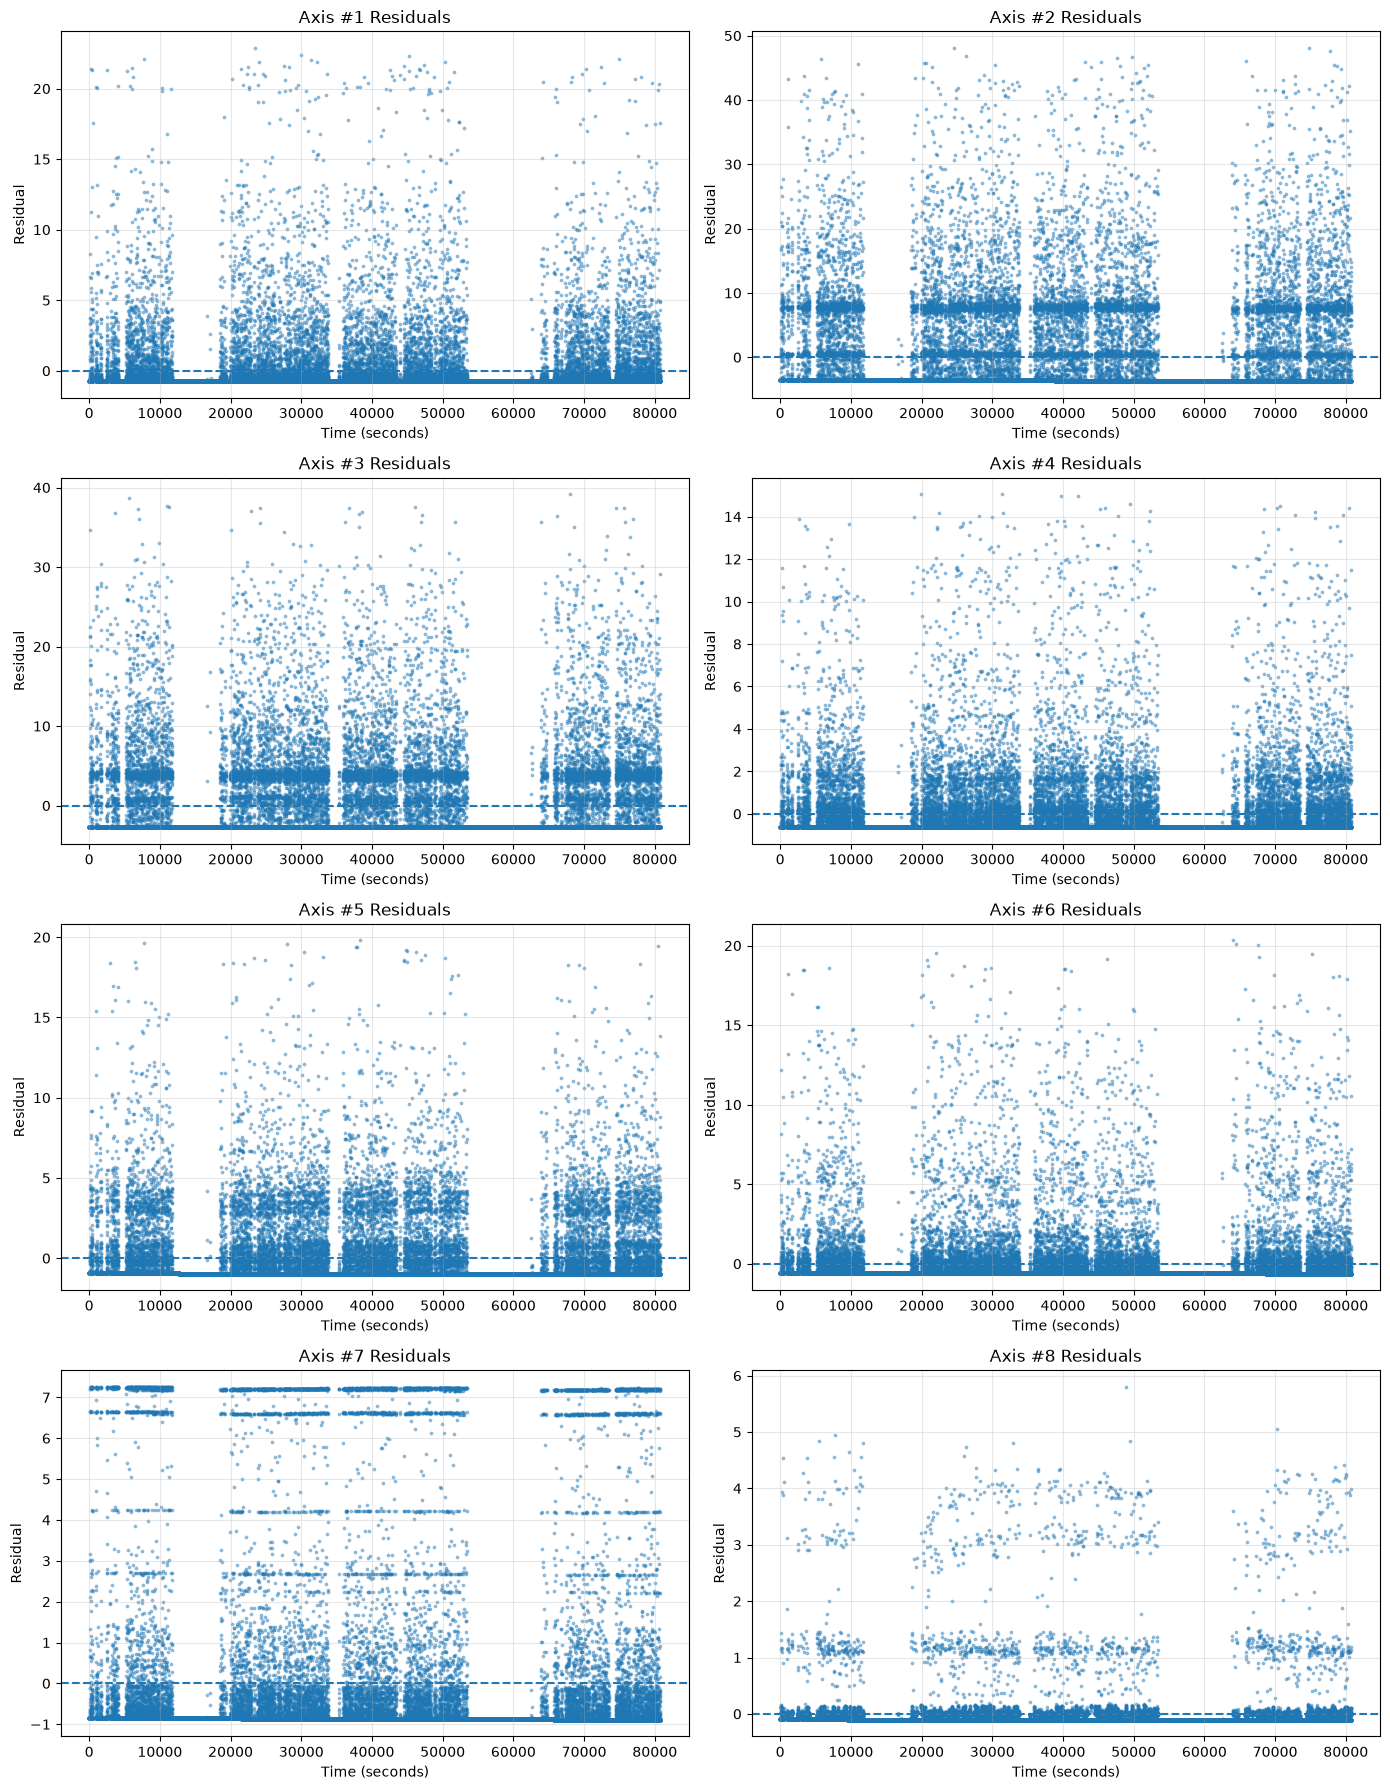

In [47]:
fig, residual_axes = plt.subplots(4, 2, figsize=(14, 18))

for i, ax in enumerate(residual_axes.flatten(), start=1):

    axis_name = f"Axis #{i}"
    residual_name = f"{axis_name}_residual"

    ax.scatter(
        df["Time_seconds"],
        df[residual_name],
        s=3,
        alpha=0.4
    )

    # Zero line = actual equals predicted
    ax.axhline(0, linestyle="--")

    ax.set_title(f"{axis_name} Residuals")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Residual")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
print(df.columns.tolist())

['Trait', 'Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14', 'Time', 'Time_seconds', 'Axis1_predicted', 'Axis1_residual', 'above_95', 'Time_gap_seconds', 'run_id', 'new_run', 'run_id_corrected', 'above_99', 'new_run_99', 'run_id_99', 'Axis #1_predicted', 'Axis #1_residual', 'Axis #2_predicted', 'Axis #2_residual', 'Axis #3_predicted', 'Axis #3_residual', 'Axis #4_predicted', 'Axis #4_residual', 'Axis #5_predicted', 'Axis #5_residual', 'Axis #6_predicted', 'Axis #6_residual', 'Axis #7_predicted', 'Axis #7_residual', 'Axis #8_predicted', 'Axis #8_residual']


## 6. Prepare synthetic test data

The notebook selects the original telemetry columns to create a clean training frame, checks its completeness, and summarizes the axis-current means and standard deviations. It then makes a reproducible test copy by adding small normally distributed noise (5% of each training axis standard deviation). The comparison table checks that this variation has not substantially changed the overall data profile.

In [49]:
print(df["Trait"].value_counts(dropna=False))

Trait
current    39672
Name: count, dtype: int64


In [50]:
print(df[["Trait", "Time"]].head(10))

     Trait                             Time
0  current 2022-10-17 12:18:23.660000+00:00
1  current 2022-10-17 12:18:25.472000+00:00
2  current 2022-10-17 12:18:27.348000+00:00
3  current 2022-10-17 12:18:29.222000+00:00
4  current 2022-10-17 12:18:31.117000+00:00
5  current 2022-10-17 12:18:32.964000+00:00
6  current 2022-10-17 12:18:34.894000+00:00
7  current 2022-10-17 12:18:36.782000+00:00
8  current 2022-10-17 12:18:38.708000+00:00
9  current 2022-10-17 12:18:40.529000+00:00


In [51]:
# These are the ORIGINAL columns from the training dataset
original_columns = [
    "Trait",
    "Axis #1",
    "Axis #2",
    "Axis #3",
    "Axis #4",
    "Axis #5",
    "Axis #6",
    "Axis #7",
    "Axis #8",
    "Axis #9",
    "Axis #10",
    "Axis #11",
    "Axis #12",
    "Axis #13",
    "Axis #14",
    "Time"
]

# Make a clean copy
training_clean = df[original_columns].copy()

print("Training data shape:", training_clean.shape)
print(training_clean.head())

Training data shape: (39672, 16)
     Trait  Axis #1  Axis #2  Axis #3  Axis #4  Axis #5  Axis #6  Axis #7  \
0  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   Axis #8  Axis #9  Axis #10  Axis #11  Axis #12  Axis #13  Axis #14  \
0      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
1      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
2      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
3      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
4      0.0      NaN       NaN       NaN       NaN       NaN       NaN   

                              Time  
0 2022-10-17 12:18:23.660000

In [52]:
print(training_clean.columns.tolist())
print()
print("Missing values:")
print(training_clean.isnull().sum())

['Trait', 'Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14', 'Time']

Missing values:
Trait           0
Axis #1         0
Axis #2         0
Axis #3         0
Axis #4         0
Axis #5         0
Axis #6         0
Axis #7         0
Axis #8         0
Axis #9     39672
Axis #10    39672
Axis #11    39672
Axis #12    39672
Axis #13    39672
Axis #14    39672
Time            0
dtype: int64


In [53]:
# Check the mean and standard deviation of our training data

axes = [f"Axis #{i}" for i in range(1, 9)]

training_stats = training_clean[axes].agg(["mean", "std"])

print(training_stats)

       Axis #1   Axis #2   Axis #3   Axis #4   Axis #5   Axis #6   Axis #7  \
mean  0.725743  3.613374  2.710336  0.620222  0.954521  0.599427  0.870145   
std   2.162120  6.879962  5.111901  1.574897  2.100186  1.815498  2.166811   

       Axis #8  
mean  0.102214  
std   0.423075  


In [54]:
# Create synthetic testing data
# We start with a copy of the training data so the metadata and time format are similar.

test_data = training_clean.copy()

print("Testing data shape:", test_data.shape)
print(test_data.head())

Testing data shape: (39672, 16)
     Trait  Axis #1  Axis #2  Axis #3  Axis #4  Axis #5  Axis #6  Axis #7  \
0  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   Axis #8  Axis #9  Axis #10  Axis #11  Axis #12  Axis #13  Axis #14  \
0      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
1      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
2      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
3      0.0      NaN       NaN       NaN       NaN       NaN       NaN   
4      0.0      NaN       NaN       NaN       NaN       NaN       NaN   

                              Time  
0 2022-10-17 12:18:23.660000+

In [55]:
import numpy as np

# Make a copy so the original training data is not changed
test_data = training_clean.copy()

# Set a fixed random seed so we get the same result every time
np.random.seed(42)

# Add a small amount of random variation to Axes #1-#8
for axis in axes:
    noise = np.random.normal(
        loc=0,
        scale=training_clean[axis].std() * 0.05,
        size=len(test_data)
    )
    
    test_data[axis] = test_data[axis] + noise

print("Synthetic test data created!")
print(test_data[axes].agg(["mean", "std"]))

Synthetic test data created!
       Axis #1   Axis #2   Axis #3   Axis #4   Axis #5   Axis #6   Axis #7  \
mean  0.725378  3.615040  2.711664  0.620260  0.954248  0.599643  0.869439   
std   2.164778  6.890427  5.117027  1.577047  2.102906  1.818578  2.168896   

       Axis #8  
mean  0.102025  
std   0.423511  


In [56]:
# Compare training data with synthetic testing data

comparison = pd.DataFrame({
    "Training Mean": training_clean[axes].mean(),
    "Testing Mean": test_data[axes].mean(),
    "Training Std": training_clean[axes].std(),
    "Testing Std": test_data[axes].std()
})

print(comparison)

         Training Mean  Testing Mean  Training Std  Testing Std
Axis #1       0.725743      0.725378      2.162120     2.164778
Axis #2       3.613374      3.615040      6.879962     6.890427
Axis #3       2.710336      2.711664      5.111901     5.117027
Axis #4       0.620222      0.620260      1.574897     1.577047
Axis #5       0.954521      0.954248      2.100186     2.102906
Axis #6       0.599427      0.599643      1.815498     1.818578
Axis #7       0.870145      0.869439      2.166811     2.168896
Axis #8       0.102214      0.102025      0.423075     0.423511


## 7. Set thresholds and create controlled test periods

Thresholds are calibrated from the Axis #1 training residuals: its 95th percentile is 3.622423 kWh (`MinC` = 3.62), and its 99th percentile is 10.637570 kWh (`MaxC` = 10.64). The timestamp gaps have a 1.891-second median and a 2.003-second 95th percentile; `T` = 4 seconds therefore requires a sustained deviation across multiple typical samples, not a single spike. These shared absolute thresholds are exploratory and may not fit every axis equally well. Alert readings are in `[MinC, MaxC)` and Error readings are `>= MaxC`; detections are split across gaps greater than five seconds. A separate stream copy preserves the source data, and controlled Axis #1 intervals are injected to test both levels.

In [ ]:
# Calibrate thresholds from the Axis #1 training residual distribution.
MinC = round(float(df["Axis1_residual"].quantile(0.95)), 2)
MaxC = round(float(df["Axis1_residual"].quantile(0.99)), 2)
T = 4

print("MinC (Axis #1 95th percentile):", MinC, "kWh")
print("MaxC (Axis #1 99th percentile):", MaxC, "kWh")
print("T (minimum continuous duration):", T, "seconds")

In [58]:
# Make a separate copy for our Alert/Error experiment

stream_data = test_data.copy()

print("Stream data created!")
print("Rows:", len(stream_data))

Stream data created!
Rows: 39672


In [59]:
# Create a controlled Alert period on Axis #1

alert_start = 10000
alert_end = 10010

# Add MinC to the normal values during this period
stream_data.loc[alert_start:alert_end, "Axis #1"] = (
    stream_data.loc[alert_start:alert_end, "Axis #1"]
    + MinC
)

print("Alert period created!")
print("Rows:", alert_start, "to", alert_end)

Alert period created!
Rows: 10000 to 10010


In [60]:
# Create a controlled Error period on Axis #1

error_start = 20000
error_end = 20010

# Add MaxC to the normal values during this period
stream_data.loc[error_start:error_end, "Axis #1"] = (
    stream_data.loc[error_start:error_end, "Axis #1"]
    + MaxC
)

print("Error period created!")
print("Rows:", error_start, "to", error_end)

Error period created!
Rows: 20000 to 20010


In [61]:
# Save the synthetic streaming data

import os

os.makedirs("data", exist_ok=True)

stream_data.to_csv(
    "data/synthetic_streaming_data.csv",
    index=False
)

print("Synthetic streaming data saved successfully!")
print("File: data/synthetic_streaming_data.csv")

Synthetic streaming data saved successfully!
File: data/synthetic_streaming_data.csv


In [62]:
# Calculate predicted values and residuals for the streaming data

stream_data["Time_seconds"] = (
    stream_data["Time"] - training_clean["Time"].min()
).dt.total_seconds()

for i in range(1, 9):
    axis_name = f"Axis #{i}"
    
    # Predict the normal value
    stream_data[f"{axis_name}_predicted"] = models[axis_name].predict(
        stream_data[["Time_seconds"]]
    )
    
    # Calculate how far the actual value is from the prediction
    stream_data[f"{axis_name}_residual"] = (
        stream_data[axis_name]
        - stream_data[f"{axis_name}_predicted"]
    )

print("Predictions and residuals calculated!")

Predictions and residuals calculated!


In [63]:
# Check the Alert test period

alert_check = stream_data.loc[
    alert_start:alert_end,
    ["Time", "Axis #1", "Axis #1_predicted", "Axis #1_residual"]
]

print(alert_check)

                                  Time   Axis #1  Axis #1_predicted  \
10000 2022-10-17 18:07:26.971000+00:00  3.546651           0.728078   
10001 2022-10-17 18:07:28.861000+00:00  3.586974           0.728077   
10002 2022-10-17 18:07:30.820000+00:00  3.685710           0.728077   
10003 2022-10-17 18:07:32.706000+00:00  7.254117           0.728077   
10004 2022-10-17 18:07:38.223000+00:00  4.166362           0.728076   
10005 2022-10-17 18:07:40.112000+00:00  5.204416           0.728076   
10006 2022-10-17 18:07:41.947000+00:00  8.366665           0.728076   
10007 2022-10-17 18:07:43.925000+00:00  3.848207           0.728076   
10008 2022-10-17 18:07:45.882000+00:00  4.674956           0.728075   
10009 2022-10-17 18:07:47.791000+00:00  3.943025           0.728075   
10010 2022-10-17 18:07:49.758000+00:00  4.032377           0.728075   

       Axis #1_residual  
10000          2.818573  
10001          2.858896  
10002          2.957632  
10003          6.526040  
10004          3.

In [64]:
# Fix the Alert period so every reading is clearly above MinC

stream_data.loc[alert_start:alert_end, "Axis #1"] = (
    stream_data.loc[alert_start:alert_end, "Axis #1_predicted"]
    + MinC
    + 1.0
)

# Recalculate the residual
stream_data.loc[alert_start:alert_end, "Axis #1_residual"] = (
    stream_data.loc[alert_start:alert_end, "Axis #1"]
    - stream_data.loc[alert_start:alert_end, "Axis #1_predicted"]
)

print(stream_data.loc[
    alert_start:alert_end,
    ["Time", "Axis #1", "Axis #1_predicted", "Axis #1_residual"]
])

                                  Time   Axis #1  Axis #1_predicted  \
10000 2022-10-17 18:07:26.971000+00:00  5.348078           0.728078   
10001 2022-10-17 18:07:28.861000+00:00  5.348077           0.728077   
10002 2022-10-17 18:07:30.820000+00:00  5.348077           0.728077   
10003 2022-10-17 18:07:32.706000+00:00  5.348077           0.728077   
10004 2022-10-17 18:07:38.223000+00:00  5.348076           0.728076   
10005 2022-10-17 18:07:40.112000+00:00  5.348076           0.728076   
10006 2022-10-17 18:07:41.947000+00:00  5.348076           0.728076   
10007 2022-10-17 18:07:43.925000+00:00  5.348076           0.728076   
10008 2022-10-17 18:07:45.882000+00:00  5.348075           0.728075   
10009 2022-10-17 18:07:47.791000+00:00  5.348075           0.728075   
10010 2022-10-17 18:07:49.758000+00:00  5.348075           0.728075   

       Axis #1_residual  
10000              4.62  
10001              4.62  
10002              4.62  
10003              4.62  
10004            

In [65]:
# Create and verify the Error period

stream_data.loc[error_start:error_end, "Axis #1"] = (
    stream_data.loc[error_start:error_end, "Axis #1_predicted"]
    + MaxC
    + 2.0
)

# Recalculate the residual
stream_data.loc[error_start:error_end, "Axis #1_residual"] = (
    stream_data.loc[error_start:error_end, "Axis #1"]
    - stream_data.loc[error_start:error_end, "Axis #1_predicted"]
)

print(stream_data.loc[
    error_start:error_end,
    ["Time", "Axis #1", "Axis #1_predicted", "Axis #1_residual"]
])

                                  Time    Axis #1  Axis #1_predicted  \
20000 2022-10-17 23:44:24.683000+00:00  13.365699           0.725699   
20001 2022-10-17 23:44:26.631000+00:00  13.365698           0.725698   
20002 2022-10-17 23:44:28.511000+00:00  13.365698           0.725698   
20003 2022-10-17 23:44:30.439000+00:00  13.365698           0.725698   
20004 2022-10-17 23:44:32.347000+00:00  13.365698           0.725698   
20005 2022-10-17 23:44:34.189000+00:00  13.365697           0.725697   
20006 2022-10-17 23:44:36.143000+00:00  13.365697           0.725697   
20007 2022-10-17 23:44:38.082000+00:00  13.365697           0.725697   
20008 2022-10-17 23:44:39.971000+00:00  13.365697           0.725697   
20009 2022-10-17 23:44:41.736000+00:00  13.365697           0.725697   
20010 2022-10-17 23:44:43.724000+00:00  13.365696           0.725696   

       Axis #1_residual  
20000             12.64  
20001             12.64  
20002             12.64  
20003             12.64  
20004

## 8. Detect and visualize Axis #1 events

Residuals are compared with the Alert and Error thresholds to create Boolean flags. The event-detection function groups consecutive flagged readings and retains periods meeting the configured minimum duration. The resulting event table is saved, and a plot overlays measured current, the regression baseline, and detected event intervals.

In [ ]:
residual = stream_data["Axis #1_residual"]
stream_data["is_alert"] = (residual >= MinC) & (residual < MaxC)
stream_data["is_error"] = residual >= MaxC
print("Alert readings:", stream_data["is_alert"].sum())
print("Error readings:", stream_data["is_error"].sum())

In [67]:
# Detect continuous Alert and Error events
# The condition must remain active for at least T seconds.

def detect_events(data, flag_column, event_type, min_duration):
    events = []
    in_event = False
    start_index = None

    for i in range(len(data)):
        current_flag = data.iloc[i][flag_column]

        if current_flag and not in_event:
            # Start a new event
            in_event = True
            start_index = i

        elif not current_flag and in_event:
            # Event ended
            end_index = i - 1

            start_time = data.iloc[start_index]["Time"]
            end_time = data.iloc[end_index]["Time"]

            duration = (end_time - start_time).total_seconds()

            if duration >= min_duration:
                events.append({
                    "Event": event_type,
                    "Axis": "Axis #1",
                    "Start Time": start_time,
                    "End Time": end_time,
                    "Duration (seconds)": duration
                })

            in_event = False
            start_index = None

    # Check if an event continues until the final row
    if in_event:
        end_index = len(data) - 1

        start_time = data.iloc[start_index]["Time"]
        end_time = data.iloc[end_index]["Time"]

        duration = (end_time - start_time).total_seconds()

        if duration >= min_duration:
            events.append({
                "Event": event_type,
                "Axis": "Axis #1",
                "Start Time": start_time,
                "End Time": end_time,
                "Duration (seconds)": duration
            })

    return events


# Detect Alerts
alert_events = detect_events(
    stream_data,
    "is_alert",
    "ALERT",
    T
)

# Detect Errors
error_events = detect_events(
    stream_data,
    "is_error",
    "ERROR",
    T
)

# Combine results
events = alert_events + error_events

events_df = pd.DataFrame(events)

print("Detected events:")
print(events_df)

Detected events:
   Event     Axis                       Start Time  \
0  ALERT  Axis #1 2022-10-17 13:24:13.851000+00:00   
1  ALERT  Axis #1 2022-10-17 18:07:26.971000+00:00   
2  ALERT  Axis #1 2022-10-17 19:08:56.362000+00:00   
3  ALERT  Axis #1 2022-10-17 20:22:12.028000+00:00   
4  ALERT  Axis #1 2022-10-17 20:53:27.054000+00:00   
5  ALERT  Axis #1 2022-10-17 23:44:24.683000+00:00   
6  ALERT  Axis #1 2022-10-17 23:59:51.069000+00:00   
7  ALERT  Axis #1 2022-10-18 07:38:43.489000+00:00   
8  ERROR  Axis #1 2022-10-17 23:44:24.683000+00:00   

                          End Time  Duration (seconds)  
0 2022-10-17 13:24:19.386000+00:00               5.535  
1 2022-10-17 18:07:49.758000+00:00              22.787  
2 2022-10-17 19:09:01.909000+00:00               5.547  
3 2022-10-17 20:22:19.431000+00:00               7.403  
4 2022-10-17 20:53:32.690000+00:00               5.636  
5 2022-10-17 23:44:45.660000+00:00              20.977  
6 2022-10-18 00:00:00.846000+00:00         

In [68]:
# Save detected Alert and Error events

import os

os.makedirs("results", exist_ok=True)

events_df.to_csv(
    "results/detected_events.csv",
    index=False
)

print("Events saved successfully!")
print("File: results/detected_events.csv")
print("Total events:", len(events_df))

Events saved successfully!
File: results/detected_events.csv
Total events: 9


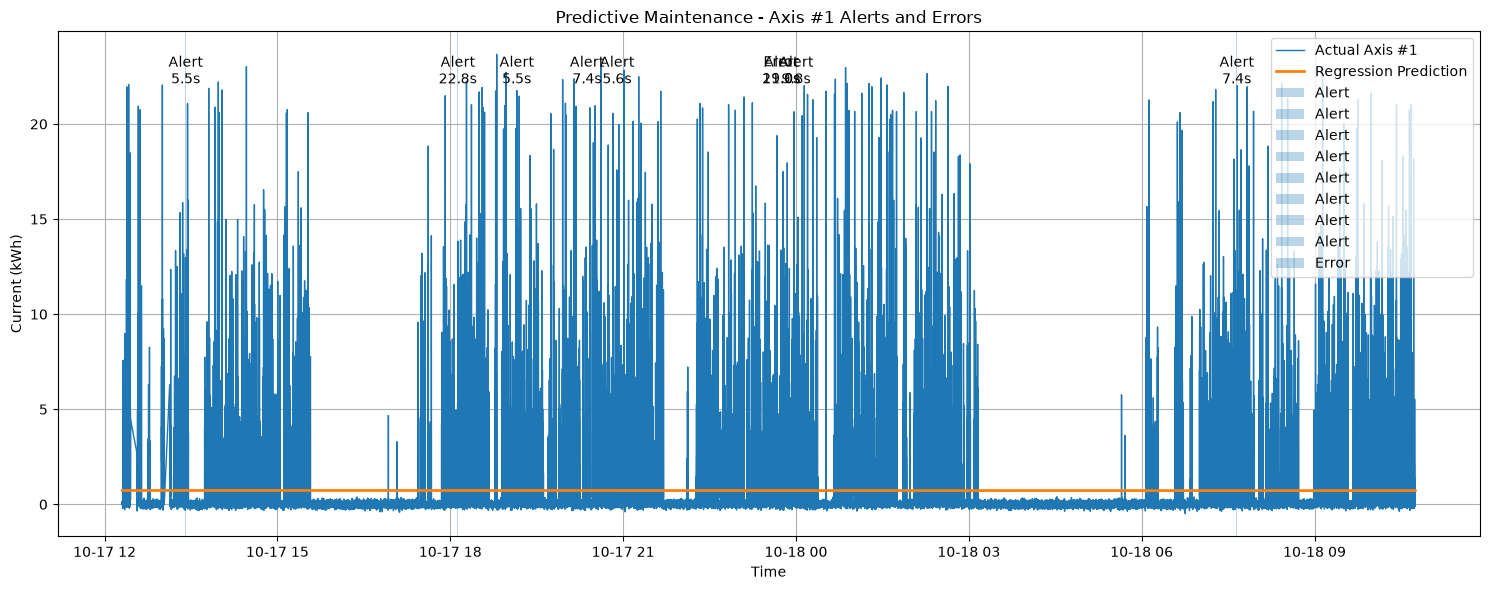

In [69]:
import matplotlib.pyplot as plt

# Plot Axis #1 actual values and regression prediction
plt.figure(figsize=(15, 6))

plt.plot(
    stream_data["Time"],
    stream_data["Axis #1"],
    label="Actual Axis #1",
    linewidth=1
)

plt.plot(
    stream_data["Time"],
    stream_data["Axis #1_predicted"],
    label="Regression Prediction",
    linewidth=2
)

# Add detected events
for _, event in events_df.iterrows():

    start = event["Start Time"]
    end = event["End Time"]

    if event["Event"] == "ALERT":
        label = "Alert"
    else:
        label = "Error"

    plt.axvspan(
        start,
        end,
        alpha=0.3,
        label=label
    )

    # Put event label in the middle
    middle_time = start + (end - start) / 2

    plt.text(
        middle_time,
        stream_data["Axis #1"].max(),
        f"{label}\n{event['Duration (seconds)']:.1f}s",
        ha="center",
        va="top"
    )

plt.title("Predictive Maintenance - Axis #1 Alerts and Errors")
plt.xlabel("Time")
plt.ylabel("Current (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## 9. Extend detection to all eight axes

The notebook applies the same residual thresholds to each axis and collects the resulting events. Later cells refine this logic to split events across long sampling gaps, save the final event table, and summarize and plot counts by axis and event type.

In [ ]:
all_events = []
for i in range(1, 9):
    axis_name = f"Axis #{i}"
    residual = stream_data[f"{axis_name}_residual"]
    stream_data["alert_flag"] = (residual >= MinC) & (residual < MaxC)
    stream_data["error_flag"] = residual >= MaxC
    axis_alerts = detect_events(stream_data, "alert_flag", "ALERT", T)
    axis_errors = detect_events(stream_data, "error_flag", "ERROR", T)
    for event in axis_alerts + axis_errors:
        event["Axis"] = axis_name
    all_events.extend(axis_alerts + axis_errors)
all_events_df = pd.DataFrame(all_events)
print("Total events detected:", len(all_events_df))
print(all_events_df)

## 10. Optional: Neon PostgreSQL training data

The notebook initializes the `cat_dc` schema and seeds the full CSV training history only when the database has no seed data. It reads the training rows back from Neon and fits regression models for all eight axes. These cells require a project-root `.env` file with `DATABASE_URL` and a reachable database.

In [71]:
# Test Neon PostgreSQL connection

from persistence.telemetry_store import TelemetryStore

store = TelemetryStore()

print("Neon database connection successful!")

Neon database connection successful!


In [73]:
print([method for method in dir(store) if not method.startswith("_")])

['ask', 'calibration_limits', 'calibration_window', 'connection', 'count', 'drop_everything', 'engine', 'has_history', 'initialise', 'minute_peaks', 'page', 'purge_stream', 'seed', 'wide', 'write']


In [74]:
for method in dir(store):
    if not method.startswith("_"):
        print(method)

ask
calibration_limits
calibration_window
connection
count
drop_everything
engine
has_history
initialise
minute_peaks
page
purge_stream
seed
wide
write


In [75]:
import inspect

print(inspect.signature(store.initialise))

(robot_name: str = 'RMBR4-2') -> None


In [76]:
store.initialise("RMBR4-2")

print("Neon database initialized successfully!")

Neon database initialized successfully!


In [77]:
print("Rows currently in Neon:", store.count())

Rows currently in Neon: 0


In [78]:
import inspect

print(inspect.signature(store.write))

(conn: sqlalchemy.engine.base.Connection, record: pandas.DataFrame, origin: str = 'stream') -> list[int]


In [79]:
print(inspect.getsource(store.write))

    def write(self, conn: Connection, record: pd.DataFrame, origin: str = "stream") -> list[int]:
        new_ids = []
        for row in record.to_dict("records"):
            sample_id = conn.execute(
                insert(sample)
                .values(
                    equipment_id=ROBOT_ID,
                    sampled_at=row["sampled_at"],
                    trait=row["trait"],
                    state=row["state"],
                    origin=origin,
                )
                .returning(sample.c.sample_id)
            ).scalar_one()
            conn.execute(
                insert(joint_current),
                [{"sample_id": sample_id, "joint_id": n, "amps": row[f"j{n}"]} for n in range(1, 9)],
            )
            new_ids.append(sample_id)
        return new_ids



In [80]:
print(inspect.getsource(store.seed))

    def seed(self, shift: pd.DataFrame) -> int:
        if self.count("seed"):
            return 0
        headers = shift.assign(sample_id=range(1, len(shift) + 1), equipment_id=ROBOT_ID, origin="seed")
        header_cols = ["sample_id", "equipment_id", "sampled_at", "trait", "state", "origin"]
        currents = headers.melt(id_vars="sample_id", value_vars=JOINTS, var_name="joint", value_name="amps")
        currents["joint_id"] = currents["joint"].str.removeprefix("j").astype(int)
        current_cols = ["sample_id", "joint_id", "amps"]

        raw = self.engine.raw_connection()
        try:
            pg = raw.driver_connection
            with pg.cursor() as cur:
                for table_name, frame, cols in (
                    ("sample", headers, header_cols),
                    ("joint_current", currents, current_cols),
                ):
                    buffer = io.StringIO()
                    frame[cols].to_csv(buffer, index=False, header=False)
                 

### Seed training data and read it back

The training frame is reshaped to the `TelemetryStore` schema (`sampled_at`, `trait`, `state`, and `j1`–`j8`). `store.seed` bulk-loads the full CSV history once; subsequent runs reuse the existing seed. The notebook reads the seeded history back from Neon as a wide table for modeling.

In [ ]:
db_training = training_clean[["Time", "Trait", *axes]].copy()
db_training = db_training.rename(columns={
    "Time": "sampled_at",
    "Trait": "trait",
    **{f"Axis #{i}": f"j{i}" for i in range(1, 9)},
})
db_training["state"] = "RUNNING"
print("Training rows prepared for Neon:", len(db_training))
display(db_training.head())

In [83]:
import inspect

print(inspect.signature(store.connection))

() -> contextlib.AbstractContextManager[sqlalchemy.engine.base.Connection]


In [87]:
with store.connection() as conn:
    result = conn.exec_driver_sql("""
        SELECT pg_get_constraintdef(oid)
        FROM pg_constraint
        WHERE conname = 'sample_state_known'
    """)
    
    print(result.scalar())

CHECK ((state = ANY (ARRAY['RUNNING'::text, 'IDLE'::text])))


In [89]:
db_training["state"] = "RUNNING"

print(db_training["state"].value_counts())

state
RUNNING    39672
Name: count, dtype: int64


In [ ]:
# Bulk-seed the full training history once; later runs reuse existing seed data.
rows_seeded = store.seed(db_training)
print("Training rows newly seeded to Neon:", rows_seeded)
print("Training rows available in Neon:", store.count("seed"))

In [94]:
print("Rows currently in Neon:", store.count())

Rows currently in Neon: 100


In [95]:
import inspect

print(inspect.signature(store.ask))

(sql: str, **params) -> pandas.DataFrame


In [ ]:
db_from_neon = store.wide(origin="seed")
print("Training readings returned from Neon:", len(db_from_neon))
display(db_from_neon.head())

In [ ]:
db_wide = db_from_neon.rename(columns={
    "sampled_at": "Time",
    **{f"j{i}": f"Axis #{i}" for i in range(1, 9)},
})
print("Database training data shape:", db_wide.shape)
display(db_wide[["Time", *axes]].head())

In [98]:
print("Database training data shape:", db_wide.shape)
print("Missing values:")
print(db_wide.isnull().sum())

Database training data shape: (100, 9)
Missing values:
Time       0
Axis #1    0
Axis #2    0
Axis #3    0
Axis #4    0
Axis #5    0
Axis #6    0
Axis #7    0
Axis #8    0
dtype: int64


### Train and compare database-backed models

The notebook fits one regression model per axis using timestamps and current values retrieved from Neon. It prints each slope and intercept, then compares the Axis #1 database model with the CSV model and checks training/test distributions.

In [ ]:
db_wide["Time_seconds"] = (
    db_wide["Time"] - db_wide["Time"].min()
).dt.total_seconds()
X_db = db_wide[["Time_seconds"]]
db_models = {}
for i in range(1, 9):
    axis_name = f"Axis #{i}"
    model = LinearRegression().fit(X_db, db_wide[axis_name])
    db_models[axis_name] = model
    db_wide[f"{axis_name}_predicted"] = model.predict(X_db)
    db_wide[f"{axis_name}_residual"] = (
        db_wide[axis_name] - db_wide[f"{axis_name}_predicted"]
    )
    print(axis_name, "| Slope:", model.coef_[0], "| Intercept:", model.intercept_)
db_model_axis1 = db_models["Axis #1"]

In [100]:
print("Original CSV model")
print("Slope:", models["Axis #1"].coef_[0])
print("Intercept:", models["Axis #1"].intercept_)

print("\nNeon database model")
print("Slope:", db_model_axis1.coef_[0])
print("Intercept:", db_model_axis1.intercept_)

Original CSV model
Slope: -1.1767285669287817e-07
Intercept: 0.730542085743738

Neon database model
Slope: 0.003744206237308272
Intercept: 0.19933006390032237


In [101]:
comparison = pd.DataFrame({
    "Training Mean": training_clean[axes].mean(),
    "Test Mean": test_data[axes].mean(),
    "Training Std": training_clean[axes].std(),
    "Test Std": test_data[axes].std()
})

display(comparison)

,Training Mean,Test Mean,Training Std,Test Std
Axis #1,0.725743,0.725378,2.162120,2.164778
Axis #2,3.613374,3.615040,6.879962,6.890427
Axis #3,2.710336,2.711664,5.111901,5.117027
Axis #4,0.620222,0.620260,1.574897,1.577047
Axis #5,0.954521,0.954248,2.100186,2.102906
Axis #6,0.599427,0.599643,1.815498,1.818578
Axis #7,0.870145,0.869439,2.166811,2.168896
Axis #8,0.102214,0.102025,0.423075,0.423511


## 11. Demonstrate a small streaming batch

These cells take a short batch from the prepared synthetic stream and classify each Axis #1 reading as NORMAL, ALERT, or ERROR according to its residual. This is a simple batch simulation of how threshold-based monitoring can report status as new readings arrive.

In [102]:
print("Streaming data rows:", len(stream_data))
print("Streaming data columns:", len(stream_data.columns))
print("Streaming data ready for monitoring.")

Streaming data rows: 39672
Streaming data columns: 37
Streaming data ready for monitoring.


In [103]:
stream_batch = stream_data.head(10).copy()

print("Streaming batch size:", len(stream_batch))
display(stream_batch[[
    "Time",
    "Axis #1",
    "Axis #1_predicted",
    "Axis #1_residual"
]])

Streaming batch size: 10


,Time,Axis #1,Axis #1_predicted,Axis #1_residual
0,2022-10-17 12:18:23.660000+00:00,0.053698,0.730542,-0.676844
1,2022-10-17 12:18:25.472000+00:00,-0.014947,0.730542,-0.745489
2,2022-10-17 12:18:27.348000+00:00,0.070019,0.730542,-0.660523
3,2022-10-17 12:18:29.222000+00:00,0.164649,0.730541,-0.565893
4,2022-10-17 12:18:31.117000+00:00,-0.025313,0.730541,-0.755855
5,2022-10-17 12:18:32.964000+00:00,-0.025312,0.730541,-0.755853
6,2022-10-17 12:18:34.894000+00:00,0.170722,0.730541,-0.559818
7,2022-10-17 12:18:36.782000+00:00,0.082964,0.730541,-0.647576
8,2022-10-17 12:18:38.708000+00:00,-0.050753,0.730540,-0.781293
9,2022-10-17 12:18:40.529000+00:00,0.058654,0.730540,-0.671886


In [104]:
for _, row in stream_batch.iterrows():
    residual = row["Axis #1_residual"]

    if residual >= MaxC:
        status = "ERROR"
    elif residual >= MinC:
        status = "ALERT"
    else:
        status = "NORMAL"

    print(
        f"Time: {row['Time']} | "
        f"Axis #1 Residual: {residual:.2f} | "
        f"Status: {status}"
    )

Time: 2022-10-17 12:18:23.660000+00:00 | Axis #1 Residual: -0.68 | Status: NORMAL
Time: 2022-10-17 12:18:25.472000+00:00 | Axis #1 Residual: -0.75 | Status: NORMAL
Time: 2022-10-17 12:18:27.348000+00:00 | Axis #1 Residual: -0.66 | Status: NORMAL
Time: 2022-10-17 12:18:29.222000+00:00 | Axis #1 Residual: -0.57 | Status: NORMAL
Time: 2022-10-17 12:18:31.117000+00:00 | Axis #1 Residual: -0.76 | Status: NORMAL
Time: 2022-10-17 12:18:32.964000+00:00 | Axis #1 Residual: -0.76 | Status: NORMAL
Time: 2022-10-17 12:18:34.894000+00:00 | Axis #1 Residual: -0.56 | Status: NORMAL
Time: 2022-10-17 12:18:36.782000+00:00 | Axis #1 Residual: -0.65 | Status: NORMAL
Time: 2022-10-17 12:18:38.708000+00:00 | Axis #1 Residual: -0.78 | Status: NORMAL
Time: 2022-10-17 12:18:40.529000+00:00 | Axis #1 Residual: -0.67 | Status: NORMAL


In [105]:
print("Total events detected:", len(all_events_df))

display(all_events_df)

Total events detected: 1910


,Event,Axis,Start Time,End Time,Duration (seconds)
0,ALERT,Axis #1,2022-10-17 13:24:13.851000+00:00,2022-10-17 13:24:19.386000+00:00,5.535
1,ALERT,Axis #1,2022-10-17 18:07:26.971000+00:00,2022-10-17 18:07:49.758000+00:00,22.787
2,ALERT,Axis #1,2022-10-17 19:08:56.362000+00:00,2022-10-17 19:09:01.909000+00:00,5.547
3,ALERT,Axis #1,2022-10-17 20:22:12.028000+00:00,2022-10-17 20:22:19.431000+00:00,7.403
4,ALERT,Axis #1,2022-10-17 20:53:27.054000+00:00,2022-10-17 20:53:32.690000+00:00,5.636
...,...,...,...,...,...
1905,ALERT,Axis #7,2022-10-18 09:56:39.129000+00:00,2022-10-18 09:56:44.883000+00:00,5.754
1906,ALERT,Axis #7,2022-10-18 10:05:26.146000+00:00,2022-10-18 10:05:31.969000+00:00,5.823
1907,ALERT,Axis #7,2022-10-18 10:10:39.978000+00:00,2022-10-18 10:10:45.494000+00:00,5.516
1908,ALERT,Axis #7,2022-10-18 10:33:33.924000+00:00,2022-10-18 10:33:39.697000+00:00,5.773


## 12. Final gap-aware event detection

The refined detector ends an event when its threshold flag clears or when successive readings are separated by a gap larger than the allowed maximum. It then evaluates Alert and Error flags for every axis using the minimum duration, reducing the chance that sparse data is treated as one continuous event.

In [108]:
def detect_events_clean(data, flag_column, event_type, axis_name, min_duration, max_gap=5):
    events = []
    in_event = False
    start_index = None

    for i in range(len(data)):
        current_flag = data.iloc[i][flag_column]

        if current_flag and not in_event:
            in_event = True
            start_index = i

        elif in_event:
            time_gap = (
                data.iloc[i]["Time"] - data.iloc[i - 1]["Time"]
            ).total_seconds()

            # End the event if the flag turns off OR there is a large time gap
            if not current_flag or time_gap > max_gap:
                end_index = i - 1

                start_time = data.iloc[start_index]["Time"]
                end_time = data.iloc[end_index]["Time"]

                duration = (end_time - start_time).total_seconds()

                if duration >= min_duration:
                    events.append({
                        "Event": event_type,
                        "Axis": axis_name,
                        "Start Time": start_time,
                        "End Time": end_time,
                        "Duration (seconds)": duration
                    })

                in_event = False
                start_index = None

                # Start a new event if the current row is also flagged
                if current_flag:
                    in_event = True
                    start_index = i

    # Handle an event that reaches the final row
    if in_event:
        end_index = len(data) - 1

        start_time = data.iloc[start_index]["Time"]
        end_time = data.iloc[end_index]["Time"]

        duration = (end_time - start_time).total_seconds()

        if duration >= min_duration:
            events.append({
                "Event": event_type,
                "Axis": axis_name,
                "Start Time": start_time,
                "End Time": end_time,
                "Duration (seconds)": duration
            })

    return events

In [ ]:
clean_events = []
for i in range(1, 9):
    axis_name = f"Axis #{i}"
    residual = stream_data[f"{axis_name}_residual"]
    stream_data["alert_flag"] = (residual >= MinC) & (residual < MaxC)
    stream_data["error_flag"] = residual >= MaxC
    clean_events.extend(detect_events_clean(
        stream_data, "alert_flag", "ALERT", axis_name, T
    ))
    clean_events.extend(detect_events_clean(
        stream_data, "error_flag", "ERROR", axis_name, T
    ))
clean_events_df = pd.DataFrame(clean_events)
print("Total clean events detected:", len(clean_events_df))
display(clean_events_df.head(20))

## 13. Summarize and visualize detected events

The final local event table is saved to `results/final_detected_events.csv`. The following cells summarize and plot event counts by axis and type; the chart is saved as `results/alert_error_events_by_axis.png` for the README.

In [110]:
os.makedirs("results", exist_ok=True)

clean_events_df.to_csv(
    "results/final_detected_events.csv",
    index=False
)

print("Final event file saved successfully!")
print("Total events:", len(clean_events_df))

Final event file saved successfully!
Total events: 1683


In [111]:
event_summary = (
    clean_events_df
    .groupby(["Axis", "Event"])
    .size()
    .reset_index(name="Count")
)

display(event_summary)

,Axis,Event,Count
0,Axis #1,ALERT,3
1,Axis #1,ERROR,1
2,Axis #2,ALERT,1118
3,Axis #2,ERROR,2
4,Axis #3,ALERT,484
5,Axis #5,ALERT,21
6,Axis #7,ALERT,54


In [112]:
print("Total events:", len(clean_events_df))
print("Summary total:", event_summary["Count"].sum())

print("\nEvents by type:")
print(clean_events_df["Event"].value_counts())

print("\nEvents by axis:")
print(clean_events_df["Axis"].value_counts())

Total events: 1683
Summary total: 1683

Events by type:
Event
ALERT    1680
ERROR       3
Name: count, dtype: int64

Events by axis:
Axis
Axis #2    1120
Axis #3     484
Axis #7      54
Axis #5      21
Axis #1       4
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import os
os.makedirs("results", exist_ok=True)
event_plot = (
    clean_events_df.groupby(["Axis", "Event"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=[f"Axis #{i}" for i in range(1, 9)],
        columns=["ALERT", "ERROR"],
        fill_value=0,
    )
)
event_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Alert and Error Events by Axis")
plt.xlabel("Axis")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.legend(title="Event Type")
plt.tight_layout()
plt.savefig("results/alert_error_events_by_axis.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Check generated project files

The final cell reports whether expected synthetic inputs, event results, chart files, project configuration files, and the local environment file are present. `.env` is optional for local analysis and should never be committed.

## 14. Stream a database-trained synthetic test batch

Database rows provide per-axis means, standard deviations, timestamps, and regression models. Test currents are generated in standardized (z-score) space with small deterministic noise, then converted back to the original current scale. Two known Axis #1 intervals are injected above thresholds calculated from database training residuals. The notebook writes only those windows as `stream` records, queries inserted IDs back from Neon, detects sustained events, and saves the event log and annotated regression plot.

In [ ]:
db_synthetic_test = db_wide[["Time", "trait", *axes]].copy()
rng = np.random.default_rng(42)
db_statistics = {}
for axis_name in axes:
    training_mean = db_wide[axis_name].mean()
    training_std = db_wide[axis_name].std()
    if pd.isna(training_std) or training_std == 0:
        raise ValueError(f"Cannot standardize {axis_name}: training standard deviation is zero or missing.")
    training_z = (db_wide[axis_name] - training_mean) / training_std
    test_z = training_z + rng.normal(0, 0.05, size=len(db_wide))
    db_synthetic_test[axis_name] = test_z * training_std + training_mean
    db_statistics[axis_name] = {
        "Training Mean": training_mean, "Test Mean": db_synthetic_test[axis_name].mean(),
        "Training Std": training_std, "Test Std": db_synthetic_test[axis_name].std(),
    }
print("Database-trained and standardized synthetic test data:")
display(pd.DataFrame(db_statistics).T)

db_synthetic_test["Time_seconds"] = (
    db_synthetic_test["Time"] - db_wide["Time"].min()
).dt.total_seconds()
for axis_name in axes:
    db_synthetic_test[f"{axis_name}_predicted"] = db_models[axis_name].predict(
        db_synthetic_test[["Time_seconds"]]
    )
    db_synthetic_test[f"{axis_name}_residual"] = (
        db_synthetic_test[axis_name] - db_synthetic_test[f"{axis_name}_predicted"]
    )

db_MinC = round(float(db_wide["Axis #1_residual"].quantile(0.95)), 2)
db_MaxC = round(float(db_wide["Axis #1_residual"].quantile(0.99)), 2)
db_T = T
window_size = 11
time_gaps = db_synthetic_test["Time"].diff().dt.total_seconds()
valid_starts = [
    start for start in range(len(db_synthetic_test) - window_size + 1)
    if time_gaps.iloc[start + 1:start + window_size].le(5).all()
]
if len(valid_starts) < 2:
    raise ValueError("Need two contiguous 11-reading windows from database training data for the stream test.")
alert_start = valid_starts[0]
error_start = next(
    (start for start in reversed(valid_starts) if start >= alert_start + window_size), None
)
if error_start is None:
    raise ValueError("Could not find two non-overlapping stream-test windows.")
alert_indices = range(alert_start, alert_start + window_size)
error_indices = range(error_start, error_start + window_size)
db_synthetic_test.loc[alert_indices, "Axis #1"] = (
    db_synthetic_test.loc[alert_indices, "Axis #1_predicted"] + db_MinC + 1.0
)
db_synthetic_test.loc[error_indices, "Axis #1"] = (
    db_synthetic_test.loc[error_indices, "Axis #1_predicted"] + db_MaxC + 2.0
)
db_synthetic_test["Axis #1_residual"] = (
    db_synthetic_test["Axis #1"] - db_synthetic_test["Axis #1_predicted"]
)

stream_indices = list(alert_indices) + list(error_indices)
db_stream_batch = db_synthetic_test.iloc[stream_indices].copy()
db_stream_write = db_stream_batch[["Time", "trait", *axes]].rename(columns={
    "Time": "sampled_at",
    **{f"Axis #{i}": f"j{i}" for i in range(1, 9)},
})
db_stream_write["state"] = "RUNNING"
with store.connection() as conn:
    new_stream_ids = store.write(conn, db_stream_write, origin="stream")
print("Synthetic stream rows written to Neon:", len(new_stream_ids))

id_params = {f"sample_id_{i}": int(sample_id) for i, sample_id in enumerate(new_stream_ids)}
id_placeholders = ", ".join(f":sample_id_{i}" for i in range(len(new_stream_ids)))
db_stream_readback = store.ask(
    f"""
    SELECT sample_id, sampled_at, trait, state, origin, j1, j2, j3, j4, j5, j6, j7, j8
    FROM cat_dc.sample_wide
    WHERE sample_id IN ({id_placeholders})
    ORDER BY sampled_at
    """,
    **id_params,
)
db_stream_readback = db_stream_readback.rename(columns={
    "sampled_at": "Time",
    **{f"j{i}": f"Axis #{i}" for i in range(1, 9)},
})
db_stream_readback["Time_seconds"] = (
    db_stream_readback["Time"] - db_wide["Time"].min()
).dt.total_seconds()
for axis_name in axes:
    db_stream_readback[f"{axis_name}_predicted"] = db_models[axis_name].predict(
        db_stream_readback[["Time_seconds"]]
    )
    db_stream_readback[f"{axis_name}_residual"] = (
        db_stream_readback[axis_name] - db_stream_readback[f"{axis_name}_predicted"]
    )

database_stream_events = []
for axis_name in axes:
    residual = db_stream_readback[f"{axis_name}_residual"]
    db_stream_readback["alert_flag"] = (residual >= db_MinC) & (residual < db_MaxC)
    db_stream_readback["error_flag"] = residual >= db_MaxC
    database_stream_events.extend(detect_events_clean(
        db_stream_readback, "alert_flag", "ALERT", axis_name, db_T
    ))
    database_stream_events.extend(detect_events_clean(
        db_stream_readback, "error_flag", "ERROR", axis_name, db_T
    ))
database_stream_events_df = pd.DataFrame(database_stream_events)
os.makedirs("results", exist_ok=True)
database_stream_events_df.to_csv("results/database_stream_events.csv", index=False)
print("Events detected from Neon read-back:", len(database_stream_events_df))
display(database_stream_events_df)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(db_stream_readback["Time"], db_stream_readback["Axis #1"], marker="o", label="Streamed Axis #1")
ax.plot(db_stream_readback["Time"], db_stream_readback["Axis #1_predicted"], linewidth=2, label="Neon regression")
for _, event in database_stream_events_df[database_stream_events_df["Axis"] == "Axis #1"].iterrows():
    color = "orange" if event["Event"] == "ALERT" else "red"
    ax.axvspan(event["Start Time"], event["End Time"], color=color, alpha=0.25)
    midpoint = event["Start Time"] + (event["End Time"] - event["Start Time"]) / 2
    ax.annotate(
        f"{event['Event']} ({event['Duration (seconds)']:.1f}s)",
        (midpoint, db_stream_readback["Axis #1"].max()), ha="center", va="top", fontsize=8,
    )
ax.set_title("Neon-Backed Synthetic Stream: Axis #1 Alerts and Errors")
ax.set_xlabel("Time")
ax.set_ylabel("Current (kWh)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("results/database_stream_alert_error.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import os
print("Important project files:")
files_to_check = [
    "data/synthetic_streaming_data.csv",
    "results/detected_events.csv",
    "results/final_detected_events.csv",
    "results/database_stream_events.csv",
    "results/alert_error_events_by_axis.png",
    "results/database_stream_alert_error.png",
    "requirements.txt", "README.md", ".gitignore", ".env",
]
for file in files_to_check:
    status = "FOUND" if os.path.exists(file) else "MISSING"
    print(f"{status}: {file}")